In [1]:
from models.model import *
from models.utils import get_weight_matrices, compute_similarity_matrix, visualize_similarity_matrix
from comparison.matrix_comparison import *
import torch
import os
from models.model import SimpleMLP
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fashion_dir = "trainedModels/fashionMNISTmodels"
fashion_model_files = sorted([f for f in os.listdir(fashion_dir) if f.endswith(".pth")])

In [3]:
input_size = 28 * 28  # MNIST images are 28x28
hidden_size = 32
output_size = 10  # 10 classes for digits 0-9

In [4]:
fashionList = []

for file in fashion_model_files:
    model_path = os.path.join(fashion_dir, file)
    model = SimpleMLP(input_size, hidden_size, output_size).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    fashionList.append(model)

print(f"Loaded {len(fashionList)} models into fashionList")

copyFashionList = fashionList.copy()


Loaded 2 models into fashionList


/tmp/ipykernel_141398/1773906525.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


In [5]:

weights_list = get_weight_matrices(fashionList[0])

# Inspecting the weights:
for idx, w in enumerate(weights_list):
    print(f"Matrix {idx}:\n{w}\n")


Matrix 0:
[[-2.6738644e-04  1.9158700e-02 -2.9394470e-02 ...  2.1935584e-02
   3.7326049e-03  2.0603326e-03]
 [ 7.7109523e-02  1.5885882e-01  3.6381613e-02 ... -9.0185747e-02
  -4.4379573e-02  9.0492591e-03]
 [-8.0879509e-02  1.8803088e-01  2.7383832e-02 ...  7.3990494e-02
   9.8019615e-02  5.6920528e-02]
 ...
 [ 1.8243959e-02 -1.9510643e-01 -3.3433754e-02 ...  1.2210296e-01
  -4.5758367e-02  6.7755668e-03]
 [ 1.9068506e-02 -2.7308159e-02  5.4033976e-03 ...  8.7511167e-03
  -3.0735526e-02  2.0047568e-02]
 [-6.1621387e-02  1.1490115e-01  2.7105701e-01 ...  6.7943521e-02
  -8.9154132e-02  6.3232318e-03]]

Matrix 1:
[[ 1.73108000e-02 -4.26602690e-03  2.24476665e-01  1.54924616e-01
  -9.14919227e-02 -3.62166196e-01  8.61749351e-02 -1.41702309e-01
  -1.91107631e-01 -1.15654826e-01 -1.51123688e-01 -7.45832920e-02
  -2.04620078e-01  1.28622845e-01  1.95615336e-01 -7.91516230e-02
  -5.35609305e-01 -3.87392342e-01 -8.95178989e-02  1.93152696e-01
   6.58568889e-02  3.29975151e-02 -2.37935260e-01

In [6]:
similarity_matrix = compute_similarity_matrix(
    modelsTrainedOnX = fashionList,
    modelsTrainedOnY = copyFashionList,
    layer=0,
    operation=MatrixComparison.matrix_difference_norm
)

In [7]:
print(similarity_matrix)

[[ 0.         11.87026119]
 [11.87026119  0.        ]]


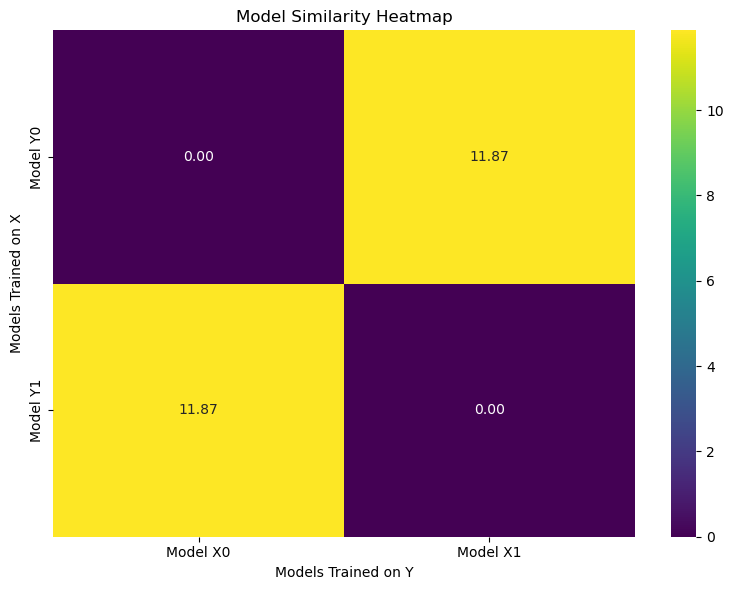

In [8]:
visualize_similarity_matrix(similarity_matrix)